***DELTA FORCE ML Task 1***


In [63]:
import numpy as np 
import pandas as pd
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub

In [64]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

In [65]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

cuda
Tesla T4


In [66]:
transform = transforms.Compose([transforms.ToTensor()])
train_dataset = datasets.MNIST(root='./data',train=True,download=True,transform=transform)
test_dataset = datasets.MNIST(root='./data',train=False,download=True,transform=transform)

In [67]:
train_loader = DataLoader(train_dataset,batch_size=64,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=64,shuffle=False)

Creating the CNN model

In [68]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.conv1 = nn.Conv2d(1,32,3,padding=1) #here we have 1 as the number of input channels, 32 as the number of output channels and 3 as the kernel size
        self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.conv3 = nn.Conv2d(64,64,3,padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.fc1 = nn.Linear(64 * 3 * 3,256)
        self.fc2 = nn.Linear(256,128)
        self.fc3 = nn.Linear(128,10)
    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))# now it becomes 32 feature maps of 14X14 size 
        x = self.pool(torch.relu(self.conv2(x)))# now it becomes 64 feature maps of 7X7 size
        x = self.pool(torch.relu(self.conv3(x)))# now it becomes 64 feature maps of 3X3 size 
        x = x.view(x.size(0),-1)
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [69]:
model = CNN().to(device)
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=576, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [70]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [86]:
epochs = 10
train_losses = []
for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for images, labels in train_loader:
        images, labels = images.to(device),labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    epoch_loss = running_loss / len(train_loader)
    accuracy = 100 * correct / total
    train_losses.append(epoch_loss)
    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:} | Accuracy: {accuracy:}%")

Epoch 1/10 | Loss: 0.12746168862455395 | Accuracy: 96.38%
Epoch 2/10 | Loss: 0.030451823362063167 | Accuracy: 99.065%
Epoch 3/10 | Loss: 0.020293531416759474 | Accuracy: 99.35833333333333%
Epoch 4/10 | Loss: 0.01680969967041599 | Accuracy: 99.49166666666666%
Epoch 5/10 | Loss: 0.012333537146488781 | Accuracy: 99.60833333333333%
Epoch 6/10 | Loss: 0.010306206639816936 | Accuracy: 99.66166666666666%
Epoch 7/10 | Loss: 0.008734721139022083 | Accuracy: 99.72833333333334%
Epoch 8/10 | Loss: 0.0073498820518445255 | Accuracy: 99.77333333333333%
Epoch 9/10 | Loss: 0.008450799323108485 | Accuracy: 99.72333333333333%
Epoch 10/10 | Loss: 0.006678259232975647 | Accuracy: 99.78166666666667%


In [87]:
model.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
accuracy = accuracy_score(all_labels, all_preds) * 100
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')
print("MNIST TEST RESULTS")
print(f"Accuracy : {accuracy:}%")
print(f"Precision: {precision:}")
print(f"Recall   : {recall:}")
print(f"F1 Score : {f1:}")

MNIST TEST RESULTS
Accuracy : 98.98%
Precision: 0.9898911344571852
Recall   : 0.9898
F1 Score : 0.9898039514049249


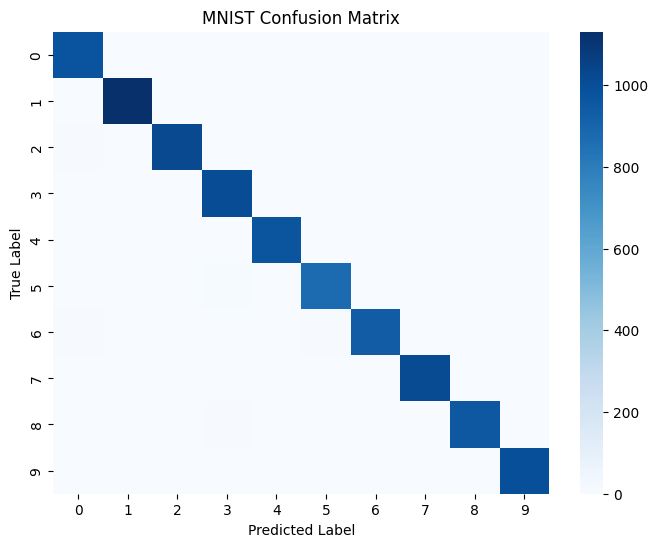

In [88]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=False,cmap="Blues")
plt.title("MNIST Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

This suggests some pretty good results because of increased number of correct results in the diagonal.

In [93]:
qmnist_test = datasets.QMNIST(root='./data',what='test',download=True,transform=transform)
qmnist_loader = DataLoader(qmnist_test,batch_size=64,shuffle=False)
model.eval()
q_preds = []
q_labels = []
with torch.no_grad():
    for images, labels in qmnist_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        q_preds.extend(predicted.cpu().numpy())
        q_labels.extend(labels.cpu().numpy())
q_accuracy = accuracy_score(q_labels, q_preds)*100
q_precision = precision_score(q_labels,q_preds,average='weighted')
q_recall = recall_score(q_labels,q_preds,average='weighted')
q_f1 = f1_score(q_labels,q_preds,average='weighted')
print("QMNIST TEST RESULTS")
print(f"Accuracy : {q_accuracy:}%")
print(f"Precision: {q_precision:}")
print(f"Recall   : {q_recall:}")
print(f"F1 Score : {q_f1:}")

QMNIST TEST RESULTS
Accuracy : 98.83166666666666%
Precision: 0.9883832204171742
Recall   : 0.9883166666666666
F1 Score : 0.9883192169039864


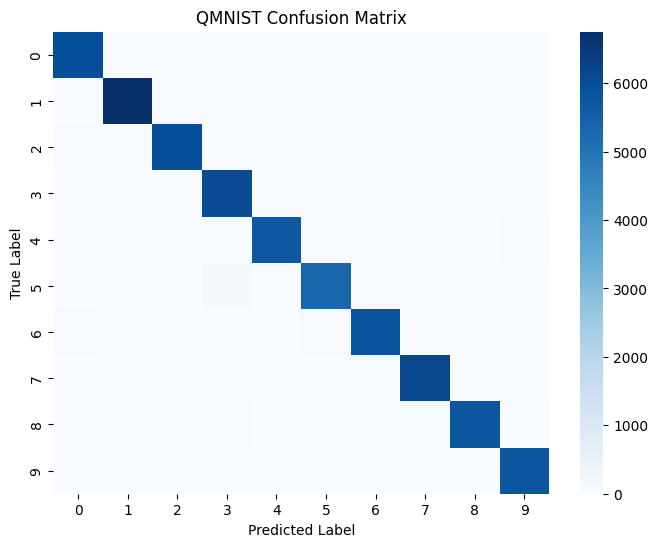

In [90]:
cm = confusion_matrix(q_labels,q_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=False,cmap="Blues")
plt.title("QMNIST Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Some of the results are off diagonal but not too much.

In [91]:
results = pd.DataFrame({
    "Dataset": ["MNIST","QMNIST"],
    "Accuracy": [accuracy,q_accuracy],
    "Precision": [precision,q_precision],
    "Recall": [recall,q_recall],
    "F1 Score": [f1,q_f1]
})
results

,Dataset,Accuracy,Precision,Recall,F1 Score
0,MNIST,98.980000,0.989891,0.989800,0.989804
1,QMNIST,98.831667,0.988383,0.988317,0.988319


The model performed has a higher accuracy with the MNIST dataset.QMNIST is more complex and has greater handwriting variations and this suggests that it contributes to lower accuracy.

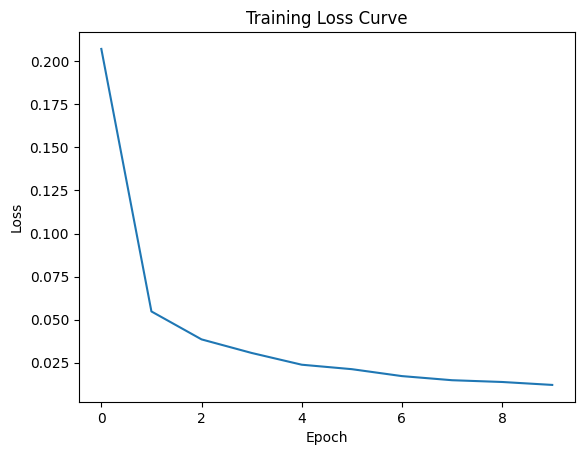

In [79]:
plt.plot(train_losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [80]:
kmnist_train = datasets.KMNIST(root="./data",train=True,download=True,transform=transform)
kmnist_test = datasets.KMNIST(root="./data",train=False,download=True,transform=transform)
kmnist_train_loader = DataLoader(kmnist_train,batch_size=64,shuffle=True)
kmnist_test_loader = DataLoader(kmnist_test,batch_size=64,shuffle=False)

In [83]:
model = CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 15
kmnist_losses = []
for epoch in range(epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0
    for images, labels in kmnist_train_loader:
        images = images.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs,labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = torch.max(outputs,1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    epoch_loss = running_loss/len(kmnist_train_loader)
    accuracy = 100 * correct/total
    kmnist_losses.append(epoch_loss)
    print(f"KMNIST Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:} | Accuracy: {accuracy:}%")

KMNIST Epoch 1/15 | Loss: 0.36186116647277117 | Accuracy: 88.17666666666666%
KMNIST Epoch 2/15 | Loss: 0.08768035760318149 | Accuracy: 97.29166666666667%
KMNIST Epoch 3/15 | Loss: 0.05424598949268333 | Accuracy: 98.325%
KMNIST Epoch 4/15 | Loss: 0.038073737594556054 | Accuracy: 98.77166666666666%
KMNIST Epoch 5/15 | Loss: 0.029639072524974615 | Accuracy: 99.065%
KMNIST Epoch 6/15 | Loss: 0.02232030725337845 | Accuracy: 99.29333333333334%
KMNIST Epoch 7/15 | Loss: 0.017872220497184108 | Accuracy: 99.43%
KMNIST Epoch 8/15 | Loss: 0.018004434063516303 | Accuracy: 99.41166666666666%
KMNIST Epoch 9/15 | Loss: 0.01404940924564727 | Accuracy: 99.55333333333333%
KMNIST Epoch 10/15 | Loss: 0.011794526815818723 | Accuracy: 99.63833333333334%
KMNIST Epoch 11/15 | Loss: 0.010692732654077138 | Accuracy: 99.655%
KMNIST Epoch 12/15 | Loss: 0.010359305767572062 | Accuracy: 99.69%
KMNIST Epoch 13/15 | Loss: 0.009950757716057712 | Accuracy: 99.68333333333334%
KMNIST Epoch 14/15 | Loss: 0.006831072710768

In [ ]:
plt.plot(kmnist_losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [61]:
model.eval()
km_preds = []
km_labels = []
with torch.no_grad():
    for images,labels in kmnist_test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs,1)
        km_preds.extend(predicted.cpu().numpy())
        km_labels.extend(labels.cpu().numpy())
accuracy = accuracy_score(km_labels,km_preds) * 100
precision = precision_score(km_labels,km_preds,average='weighted')
recall = recall_score(km_labels,km_preds,average='weighted')
f1 = f1_score(km_labels,km_preds,average='weighted')
print("KMNIST Test Results")
print(f"Accuracy : {accuracy:}%")
print(f"Precision: {precision:}")
print(f"Recall   : {recall:}")
print(f"F1 Score : {f1:}")

KMNIST Test Results
Accuracy : 96.47%
Precision: 0.9650732466733638
Recall   : 0.9647
F1 Score : 0.9646503429669067


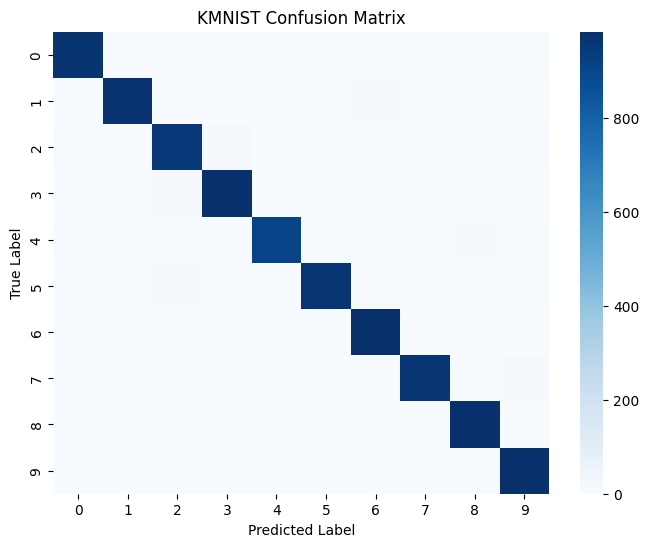

In [94]:
cm = confusion_matrix(km_labels,km_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=False,cmap="Blues")
plt.title("KMNIST Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Most counts are on the diagonal suggesting a pretty good model.

Fine-tuning the KMNIST trained model

In [45]:
import copy
modelfinetune = copy.deepcopy(model).to(device)
criterion = nn.CrossEntropyLoss()
optimizerfinetune = torch.optim.Adam(modelfinetune.parameters(),lr=0.00001)
epochs = 10
bestaccuracy = 0.0
bestepoch = 0
finetune_losses = []
print("KMNIST Fine-Tuning")
for epoch in range(epochs):
    modelfinetune.train()
    epochloss = 0.0
    correct = 0
    total = 0
    for images, labels in kmnist_train_loader:
        images, labels = images.to(device),labels.to(device)
        optimizerfinetune.zero_grad()
        outputs = modelfinetune(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizerfinetune.step()
        epochloss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    avgloss = epochloss/len(kmnist_train_loader)
    finetune_losses.append(avgloss)
    accuracy = 100 * correct/total
    print(f"Epoch {epoch+1}/{epochs} | Loss: {avgloss:} | Accuracy: {accuracy:}%")

KMNIST Fine-Tuning
Epoch 1/10 | Loss: 0.003558351451273939 | Accuracy: 99.89333333333333%
Epoch 2/10 | Loss: 0.0018866575135224504 | Accuracy: 99.95%
Epoch 3/10 | Loss: 0.0012094872573011255 | Accuracy: 99.97166666666666%
Epoch 4/10 | Loss: 0.000833896904019048 | Accuracy: 99.98166666666667%
Epoch 5/10 | Loss: 0.0005914517359312815 | Accuracy: 99.98666666666666%
Epoch 6/10 | Loss: 0.00041544783712090216 | Accuracy: 99.99333333333334%
Epoch 7/10 | Loss: 0.00029651370547645236 | Accuracy: 99.995%
Epoch 8/10 | Loss: 0.00021438440008143204 | Accuracy: 100.0%
Epoch 9/10 | Loss: 0.0001617833914179934 | Accuracy: 100.0%
Epoch 10/10 | Loss: 0.00012168515757970635 | Accuracy: 100.0%


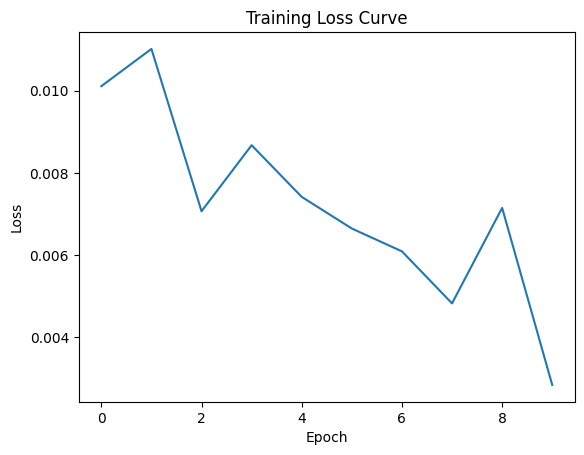

In [47]:
plt.plot(train_losses)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

This curve pattern could be because the optimizer is shifting around the very small values of losses and fine0tuning is adjusting the values even at really high accuracy causing slight increases in the loss.

In [58]:
finekm_preds = []
finekm_labels = []
with torch.no_grad():
    for images, labels in kmnist_test_loader:
        images = images.to(device)
        outputs = modelfinetune(images)
        _, predicted = torch.max(outputs, 1)
        finekm_preds.extend(predicted.cpu().numpy())
        finekm_labels.extend(labels.cpu().numpy())
fine_accuracy = accuracy_score(finekm_labels,finekm_preds) * 100
fine_precision = precision_score(finekm_labels,finekm_preds, average='weighted')
fine_recall = recall_score(finekm_labels, finekm_preds, average='weighted')
fine_f1 = f1_score(finekm_labels,finekm_preds, average='weighted')
print("KMNIST Fine-Tuned Model Results")
print(f"Accuracy : {fine_accuracy:}%")
print(f"Precision: {fine_precision:}")
print(f"Recall   : {fine_recall:}")
print(f"F1 Score : {fine_f1:}")

KMNIST Fine-Tuned Model Results
Accuracy : 97.11999999999999%
Precision: 0.9713666314287271
Recall   : 0.9712
F1 Score : 0.9711821984693528


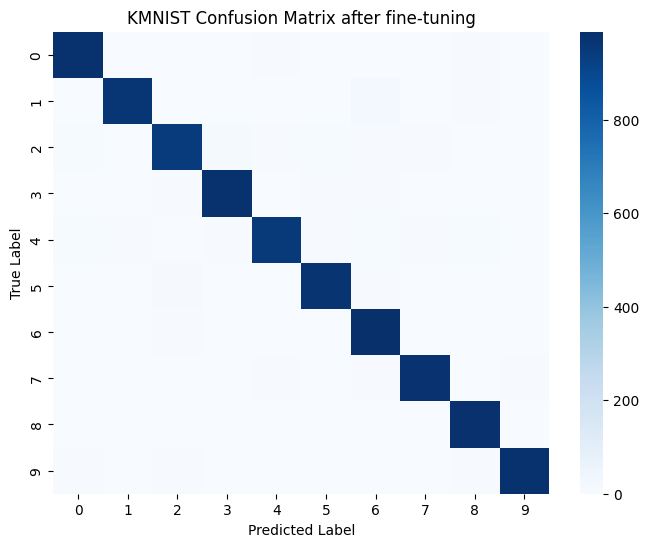

In [95]:
cm = confusion_matrix(finekm_labels,finekm_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=False,cmap="Blues")
plt.title("KMNIST Confusion Matrix after fine-tuning")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Most counts are on the diagonal and hence it is pretty strong.

The model reaches 100% accuracy really quickly from epoch 8 in the training which shows that there is a degree of overfitting to the data and generalization is also happening well because test accuracy is about 97%.

The accuracy decreased here than previously.
This could be happening because model is overfitting to the dataset or the learning rate is too high.
Both lr and number of epochs is adjusted.
It could also be becuase the previous accuracy is already very high and now fine-tuning is pushing it away from the previous accuracy.